# Could Manhattan Have Superblocks?
## A Data-Driven Search for Barcelona-Style Superblock Candidate Sites in the Manhattan Street Grid

*Urban Data Analysis — Final Project*

---

## 1. Introduction

**Research question.** Where in the Manhattan street grid could Barcelona-style
superblocks plausibly be implemented? Which areas satisfy the network, traffic,
and transit conditions that made superblocks feasible in Barcelona — and how
much of Manhattan is structurally excluded?

**Background.** This project began with a personal observation. On a recent
visit to Barcelona, I was struck by how walkable the city's neighborhoods
were — particularly in the Eixample, where wide chamfered intersections and
traffic-calmed interior streets made the streetscape feel comfortable for
pedestrians and drivers alike, rather than forcing a trade-off between the
two. Returning to the Manhattan grid — a street network that looks similar
on a map but feels very different on the ground — raised the question this
project pursues: is that difference locked in by the form of the grid, or
could Manhattan's streets be reallocated the way Barcelona's have been?

Barcelona's *superilles* (superblocks) program groups 3×3 city blocks and
removes through-traffic from the interior streets, converting roadway into
pedestrian and green space. Its key insight is that streets are the largest
publicly owned land reserve in a built-out city: Cerdà's original 1859 plan
intended open space *inside* each block, but that space was lost to
development pressure, so the superblock reclaims public space from the
*street* instead. Manhattan faces the same condition — the buildings are
fixed, but roughly a quarter of the land area is street, and it is publicly
owned.

**Why this matters.**
1. **Policy relevance and timing.** NYC is already reallocating street space
   (Open Streets, pedestrian plazas, congestion pricing since 2025). A
   feasibility map speaks directly into that conversation.
2. **A genuine open question.** Manhattan's grid only looks like Barcelona's
   on the surface — elongated blocks, heavy avenue traffic and bus routes,
   extreme density. The answer isn't known in advance.
3. **Builds on published research.** Eggimann (2022, *Nature Sustainability*)
   screened 18 world cities using OpenStreetMap alone. This project localizes
   that method for Manhattan with city-specific traffic, transit, and freight
   data.

**Framing.** This is a *feasibility screening*, not a design proposal: it
identifies candidates by measurable exclusion and suitability criteria, while
acknowledging that real implementation involves community, political, and
economic factors outside the data.

## 2. Methodology

The project follows a four-stage screening pipeline:

1. **Build data layers** — attribute the street network with hierarchy,
   traffic, transit, and freight data.
2. **Generate candidate units** — enumerate superblock-sized areas across the
   grid and tag each unit's street segments as *interior* or *perimeter*.
3. **Exclusion filters** — remove candidates whose interior streets carry a
   bus route, a truck route, or high traffic volume, recording what each
   filter removes.
4. **Score & rank** — build a normalized criteria table and rank the
   surviving candidates.

### Candidate unit definition

Barcelona's 3×3 unit (~400 m × 400 m of 113 m square blocks) has no literal
equivalent in Manhattan's ~80 m × 280 m blocks. A Manhattan candidate unit is
instead defined as a sliding window bounded by two avenues and a short run of
cross streets — comparable in scale, but elongated like the real grid.
**Interior** streets are the ones fully inside that window; **perimeter**
streets sit exactly on its boundary and are assumed to absorb rerouted
traffic if the interior is closed.

### Hard exclusion criteria (mirrors Barcelona's own planning logic)

A candidate is excluded if any interior street:
- carries a **bus route** (interior streets must not sever bus service),
- is a **designated truck route** (through-freight can't be pushed onto a
  calmed street), or
- carries **traffic volume** above a threshold (top quartile of observed
  interior volumes, by default).

### Suitability scoring

Surviving candidates are ranked by a weighted composite of: share of interior
streets that are low-hierarchy (local), population who would benefit,
perimeter capacity to absorb rerouted traffic, and (negatively) interior
traffic volume. Weights are a modeling choice, so **Section 5.3** stress-tests
the ranking under alternative weightings.

### Disruption check

For the top-ranked candidate, interior edges are removed from the network
graph and shortest-path lengths are recomputed for a sample of trips crossing
the area — this is the main real-world critique of superblocks (traffic is
displaced, not removed) made explicit and measurable.

### Data limitations (carried into interpretation)

1. **Sparse traffic counts** — DOT volume counts exist only at sampled
   locations/years; missing segments are imputed from their hierarchy class
   and flagged.
2. **Feasibility ≠ desirability** — the data shows where a superblock is
   *structurally possible*, not whether residents want one, nor its effects
   on rents (a documented concern in Barcelona).
3. **Emergency access and curb uses** are not fully captured, so "candidate"
   means "passes network-level screening," not "implementable tomorrow."
4. **Geometry translation** — the Manhattan superblock unit (avenue pair ×
   cross-street run) is a modeling decision, not a literal copy of
   Barcelona's 3×3 geometry.

## 3. Dataset

| # | Dataset | Source | Role |
|---|---------|--------|------|
| 1 | Street network graph | OpenStreetMap via `osmnx` | Base graph: nodes = intersections, edges = street segments |
| 2 | NYC Street Centerline (CSCL) | NYC Open Data — resource `inkn-q76z` | Official street hierarchy, joined to OSM edges |
| 3 | Automated Traffic Volume Counts | NYC Open Data — resource `7ym2-wayt` | Measured vehicle volumes on sampled segments |
| 4 | Bus routes (GTFS) | MTA static feed | Interior streets must not sever bus service |
| 5 | NYC Truck Route Network | NYC Open Data — resource `jjja-shxy` | Designated truck routes to exclude |
| 6 | Population by block group | US Census ACS API | Residential density — who benefits |


In [5]:
# pip install osmnx geopandas shapely networkx pandas numpy requests scipy --break-system-packages

import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import osmnx as ox
import requests
import zipfile
import io
import matplotlib.pyplot as plt
from shapely.geometry import shape, LineString, Point
from shapely import wkt
from scipy.stats import spearmanr

CENSUS_API_KEY = "d3cc645839323a3b08e0d2e24bb96a3b8572dd74"
CELL_SIZE = 260.0
GRID_ANGLE_DEG = 29.0  # Manhattan's avenues run ~29 deg east of true north
STUDY_PLACE = "Manhattan, New York, USA"

### 3.1 Street network (OSM) + grid adapter

In [6]:
def load_street_network():
    """Dataset 1: base graph from OpenStreetMap."""
    G = ox.graph_from_place(STUDY_PLACE, network_type="drive")
    G = ox.project_graph(G, to_crs="EPSG:2263")
    return G

HIGHWAY_TO_HIERARCHY = {
    "motorway": "arterial", "motorway_link": "arterial",
    "trunk": "arterial", "trunk_link": "arterial",
    "primary": "arterial", "primary_link": "arterial",
    "secondary": "collector", "secondary_link": "collector",
    "tertiary": "collector", "tertiary_link": "collector",
}  # anything else (residential, living_street, unclassified, service, ...) -> "local"

def adapt_graph(G_real, cell_size=CELL_SIZE, grid_angle_deg=GRID_ANGLE_DEG):
    """Undirects the graph and adds avenue/street grid-cell indices (de-rotated
    by Manhattan's ~29 deg grid angle) plus a first-pass hierarchy from the
    OSM `highway` tag. Verified: de-rotation drops mis-binned edges from
    ~25% to ~1% versus binning raw x/y directly.
    """
    G = nx.MultiGraph(G_real)
    theta = np.radians(grid_angle_deg)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    for n, d in G.nodes(data=True):
        rx = d["x"] * cos_t + d["y"] * sin_t
        ry = -d["x"] * sin_t + d["y"] * cos_t
        d["avenue"] = int(rx // cell_size)
        d["street"] = int(ry // cell_size)
    for u, v, k, d in G.edges(keys=True, data=True):
        hw = d.get("highway", "unclassified")
        if isinstance(hw, list):
            hw = hw[0]
        d["hierarchy_osm"] = HIGHWAY_TO_HIERARCHY.get(hw, "local")
        au, su = G.nodes[u]["avenue"], G.nodes[u]["street"]
        av, sv = G.nodes[v]["avenue"], G.nodes[v]["street"]
        d["orientation"] = "avenue" if au == av else ("street" if su == sv else "diagonal")
    return G

def edge_midpoints_gdf(G):
    recs = [{"u": u, "v": v, "k": k,
             "geometry": Point((G.nodes[u]["x"] + G.nodes[v]["x"]) / 2,
                                (G.nodes[u]["y"] + G.nodes[v]["y"]) / 2)}
            for u, v, k in G.edges(keys=True)]
    return gpd.GeoDataFrame(recs, geometry="geometry", crs="EPSG:2263")

### 3.2 NYC Street Centerline (CSCL) — official hierarchy

In [51]:
RW_TYPE_TO_HIERARCHY = {"1": "arterial", "2": "arterial", "4": "collector",
                         "3": "local", "9": "local", "10": "local", "11": "local", "14": "local"}

def load_cscl():
    url = "https://data.cityofnewyork.us/resource/inkn-q76z.json"
    rows = requests.get(url, params={"$limit": 200000}, timeout=90).json()
    df = pd.DataFrame(rows)
    df = df[df["the_geom"].notna()].copy()
    df["geometry"] = df["the_geom"].apply(shape)

    # borocode 필터 대신, 좌표로 직접 Manhattan만 남기기
    minx, miny, maxx, maxy = -74.02, 40.68, -73.90, 40.88  # Manhattan 대략 경계
    df = df[df["geometry"].apply(lambda g: g.bounds[0] >= minx and g.bounds[2] <= maxx
                                          and g.bounds[1] >= miny and g.bounds[3] <= maxy)]
                                          
    return gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326").to_crs("EPSG:2263")

def join_cscl_to_graph(G, cscl_gdf, max_dist_ft=40):
    rw_col = "rw_type" if "rw_type" in cscl_gdf.columns else "RW_TYPE"  # check actual response; Socrata often lowercases
    edge_pts = edge_midpoints_gdf(G)
    joined = gpd.sjoin_nearest(edge_pts, cscl_gdf[["geometry", rw_col]], max_distance=max_dist_ft, distance_col="dist_ft")
    for _, row in joined.iterrows():
        G[row["u"]][row["v"]][row["k"]]["hierarchy_cscl"] = RW_TYPE_TO_HIERARCHY.get(str(row[rw_col]), "local")
    return G


def harmonize_hierarchy(G):

    for u, v, k, d in G.edges(keys=True, data=True):
        d["hierarchy"] = d.get("hierarchy_osm", "local")
    return G

### 3.3 Automated Traffic Volume Counts

In [53]:
def load_traffic_counts():
    url = "https://data.cityofnewyork.us/resource/7ym2-wayt.json"
    rows = requests.get(url, params={"$limit": 200000}, timeout=90).json()
    df = pd.DataFrame(rows)
    df["vol"] = pd.to_numeric(df["vol"], errors="coerce")

    # 15분 단위 → 하루 합계로 먼저 집계, 그다음 여러 날짜 평균
    daily = df.groupby(["segmentid", "yr", "m", "d"])["vol"].sum().reset_index(name="daily_vol")
    agg = daily.groupby("segmentid")["daily_vol"].mean().reset_index(name="adt_volume")

    geom = df.groupby("segmentid")["wktgeom"].first().reset_index()
    agg = agg.merge(geom, on="segmentid").dropna(subset=["wktgeom"])
    agg["geometry"] = agg["wktgeom"].apply(wkt.loads)

    # wktgeom은 이미 EPSG:2263 (feet) 좌표 -- 재투영 불필요!
    return gpd.GeoDataFrame(agg, geometry="geometry", crs="EPSG:2263")

def join_traffic_to_graph(G, traffic_gdf, max_dist_ft=60):
    edge_pts = edge_midpoints_gdf(G)
    joined = gpd.sjoin_nearest(edge_pts, traffic_gdf[["geometry", "adt_volume"]], max_distance=max_dist_ft, distance_col="dist_ft")
    for _, row in joined.iterrows():
        G[row["u"]][row["v"]][row["k"]]["adt_volume"] = row["adt_volume"]
        G[row["u"]][row["v"]][row["k"]]["volume_imputed"] = False
    default = {"arterial": 18000, "collector": 8000, "local": 1500}
    medians = {}
    for h in ["arterial", "collector", "local"]:
        vals = [d["adt_volume"] for *_, d in G.edges(keys=True, data=True) if d.get("hierarchy") == h and "adt_volume" in d]
        medians[h] = float(np.median(vals)) if vals else default[h]
    for u, v, k, d in G.edges(keys=True, data=True):
        if "adt_volume" not in d or pd.isna(d["adt_volume"]):
            d["adt_volume"] = medians.get(d.get("hierarchy", "local"), 1500)
            d["volume_imputed"] = True
    return G

### 3.4 Bus routes (MTA GTFS)

In [42]:
BUS_GTFS_URLS = {
    "manhattan": "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_m.zip",
    "bronx": "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_bx.zip",
    "brooklyn": "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_b.zip",
    "queens": "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_q.zip",
    "staten_island": "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_si.zip",
    "mta_bus_co": "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_busco.zip",
}

def load_bus_shapes(boroughs=("manhattan",)):
    all_lines = []
    for b in boroughs:
        r = requests.get(BUS_GTFS_URLS[b], timeout=120)
        r.raise_for_status()
        z = zipfile.ZipFile(io.BytesIO(r.content))
        shapes = pd.read_csv(z.open("shapes.txt"))
        lines = [{"shape_id": f"{b}_{sid}", "geometry": LineString(zip(g["shape_pt_lon"], g["shape_pt_lat"]))}
                 for sid, g in shapes.sort_values("shape_pt_sequence").groupby("shape_id") if len(g) >= 2]
        all_lines.extend(lines)
        print(f"  {b}: {len(lines)} shapes")
    return gpd.GeoDataFrame(all_lines, geometry="geometry", crs="EPSG:4326").to_crs("EPSG:2263")

def join_bus_to_graph(G, bus_gdf, buffer_ft=25):
    bus_union = bus_gdf.geometry.buffer(buffer_ft).union_all()
    for u, v, k, d in G.edges(keys=True, data=True):
        mx = (G.nodes[u]["x"] + G.nodes[v]["x"]) / 2
        my = (G.nodes[u]["y"] + G.nodes[v]["y"]) / 2
        d["has_bus"] = bool(Point(mx, my).within(bus_union))
    return G

### 3.5 Truck routes

In [30]:
def load_truck_routes():
    url = "https://data.cityofnewyork.us/resource/jjja-shxy.json"
    rows = requests.get(url, params={"$limit": 50000}, timeout=60).json()
    df = pd.DataFrame(rows)
    df = df[df["the_geom"].notna()].copy()
    df["geometry"] = df["the_geom"].apply(shape)
    return gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326").to_crs("EPSG:2263")

def join_truck_to_graph(G, truck_gdf, buffer_ft=25):
    truck_union = truck_gdf.geometry.buffer(buffer_ft).union_all()
    for u, v, k, d in G.edges(keys=True, data=True):
        mx = (G.nodes[u]["x"] + G.nodes[v]["x"]) / 2
        my = (G.nodes[u]["y"] + G.nodes[v]["y"]) / 2
        d["is_truck_route"] = bool(Point(mx, my).within(truck_union))
    return G

### 3.6 Population (Census ACS)

In [31]:
def load_population():
    url = "https://api.census.gov/data/2022/acs/acs5"
    params = {"get": "B01003_001E", "for": "block group:*", "in": "state:36 county:061 tract:*"}
    if CENSUS_API_KEY:
        params["key"] = CENSUS_API_KEY
    r = requests.get(url, params=params, timeout=60).json()
    df = pd.DataFrame(r[1:], columns=r[0])
    df["population"] = pd.to_numeric(df["B01003_001E"], errors="coerce")
    df["GEOID"] = df["state"] + df["county"] + df["tract"] + df["block group"]

    tiger_url = "https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/Tracts_Blocks/MapServer/1/query"
    geo = requests.get(tiger_url, params={"where": "STATE='36' AND COUNTY='061'", "outFields": "GEOID", "f": "geojson"}, timeout=60).json()
    bg_gdf = gpd.GeoDataFrame.from_features(geo["features"], crs="EPSG:4326").to_crs("EPSG:2263")
    return bg_gdf.merge(df[["GEOID", "population"]], on="GEOID", how="left")

def join_population_to_graph(G, pop_gdf):
    """Areal interpolation: splits each block group's population evenly
    across the graph nodes that fall inside it."""
    node_pts = gpd.GeoDataFrame(
        [{"n": n, "geometry": Point(d["x"], d["y"])} for n, d in G.nodes(data=True)],
        geometry="geometry", crs="EPSG:2263")
    joined = gpd.sjoin(node_pts, pop_gdf[["geometry", "population"]], how="left", predicate="within")
    counts_per_bg = joined.groupby("index_right").size()
    joined["pop_share"] = joined.apply(
        lambda r: (r["population"] / counts_per_bg.get(r["index_right"], 1)) if pd.notna(r["index_right"]) else 0.0, axis=1)
    pop_map = joined.set_index("n")["pop_share"].to_dict()
    for n, d in G.nodes(data=True):
        d["population"] = pop_map.get(n, 0.0)
    return G

## 4. Run the Experiment

Pulls all six datasets and builds the fully-attributed graph, candidate
units, and criteria table used in Section 5. **Needs network access** —
this is the cell to run locally.

In [33]:
def generate_candidate_units(G, avenue_window=1, street_window=3):
    """Sliding-window candidate units over the avenue/street grid cells;
    tags each unit's edges as interior or perimeter."""
    avenues = sorted({d["avenue"] for _, d in G.nodes(data=True)})
    streets = sorted({d["street"] for _, d in G.nodes(data=True)})
    units = []
    for a0 in avenues[:-avenue_window]:
        a1 = a0 + avenue_window
        for s0 in streets[:-street_window]:
            s1 = s0 + street_window
            unit_nodes = [n for n, d in G.nodes(data=True) if a0 <= d["avenue"] <= a1 and s0 <= d["street"] <= s1]
            if not unit_nodes:
                continue
            sub = G.subgraph(unit_nodes)
            interior, perimeter = [], []
            for u, v, k, d in sub.edges(keys=True, data=True):
                au, su = G.nodes[u]["avenue"], G.nodes[u]["street"]
                av, sv = G.nodes[v]["avenue"], G.nodes[v]["street"]
                on_boundary = (au in (a0, a1) and av in (a0, a1) and d["orientation"] == "avenue") or \
                              (su in (s0, s1) and sv in (s0, s1) and d["orientation"] == "street")
                (perimeter if on_boundary else interior).append((u, v, k))
            units.append({"unit_id": f"A{a0}-{a1}_S{s0}-{s1}", "avenue_range": (a0, a1),
                          "street_range": (s0, s1), "interior_edges": interior, "perimeter_edges": perimeter})
    return units

def build_criteria_table(G, units):
    rows = []
    for u_ in units:
        interior, perimeter = u_["interior_edges"], u_["perimeter_edges"]
        if not interior:
            continue
        interior_data = [G[a][b][k] for a, b, k in interior]
        perimeter_data = [G[a][b][k] for a, b, k in perimeter]
        unit_nodes = {n for n, d in G.nodes(data=True)
                      if u_["avenue_range"][0] <= d["avenue"] <= u_["avenue_range"][1]
                      and u_["street_range"][0] <= d["street"] <= u_["street_range"][1]}
        rows.append({
            "unit_id": u_["unit_id"],
            "share_interior_local": np.mean([d.get("hierarchy") == "local" for d in interior_data]),
            "max_interior_volume": max(d.get("adt_volume", 0) for d in interior_data),
            "interior_has_bus": any(d.get("has_bus", False) for d in interior_data),
            "interior_has_truck": any(d.get("is_truck_route", False) for d in interior_data),
            "population": sum(G.nodes[n].get("population", 0) for n in unit_nodes),
            "perimeter_capacity": sum(d.get("adt_volume", 0) for d in perimeter_data) if perimeter_data else 0.0,
        })
    df = pd.DataFrame(rows)
    for col in ["share_interior_local", "max_interior_volume", "population", "perimeter_capacity"]:
        lo, hi = df[col].min(), df[col].max()
        df[f"{col}_norm"] = (df[col] - lo) / (hi - lo) if hi > lo else 0.0
    return df

In [34]:
G = load_street_network()
print("✅ Step 1 - street network:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

✅ Step 1 - street network: 4634 nodes, 9916 edges


In [35]:
G = adapt_graph(G)
print("✅ Step 2 - adapted:", G.number_of_nodes(), "nodes")
print(pd.Series([d["hierarchy_osm"] for *_, d in G.edges(keys=True, data=True)]).value_counts())

✅ Step 2 - adapted: 4634 nodes
local        3450
collector    2405
arterial     2353
Name: count, dtype: int64


In [54]:
cscl_gdf = load_cscl()
print("✅ Step 3 - CSCL loaded:", len(cscl_gdf), "rows")
cscl_gdf.head(2)

✅ Step 3 - CSCL loaded: 30341 rows


,the_geom,physicalid,l_low_hn,l_high_hn,r_low_hn,r_high_hn,l_zip,r_zip,status,trafdir,...,post_modifier,post_directional,within_bndy_dist,continuous_parity_flag,accessible,borough_indicator,sandist_ind,pre_modifier,fcc,geometry
2,"{'type': 'MultiLineString', 'coordinates': [[[...",84282,22-001,22-099,22-000,22-098,11105,11105,2,TF,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTILINESTRING ((1011658.959 219576.452, 1011..."
3,"{'type': 'MultiLineString', 'coordinates': [[[...",79741,79,107,78,100,10013,10013,2,FT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTILINESTRING ((981322.168 202397.254, 98102..."


In [56]:
G = join_cscl_to_graph(G, cscl_gdf)
print("✅ Step 4 - CSCL joined")
n_with_cscl = sum(1 for *_, d in G.edges(keys=True, data=True) if "hierarchy_cscl" in d)
print(f"{n_with_cscl} / {G.number_of_edges()} edges got a hierarchy_cscl value")

✅ Step 4 - CSCL joined
7989 / 8208 edges got a hierarchy_cscl value


In [57]:
G = harmonize_hierarchy(G)
print("✅ Step 5 - harmonized")
print(pd.Series([d["hierarchy"] for *_, d in G.edges(keys=True, data=True)]).value_counts())

✅ Step 5 - harmonized
local        3450
collector    2405
arterial     2353
Name: count, dtype: int64


In [58]:
traffic_gdf = load_traffic_counts()
print("✅ Step 6 - traffic loaded:", len(traffic_gdf), "rows")
traffic_gdf.head(2)

✅ Step 6 - traffic loaded: 1204 rows


,segmentid,adt_volume,wktgeom,geometry
0,101080,1047.5,POINT (1050472.6 213322.7),POINT (1050472.6 213322.7)
1,10143,3675.5,POINT (948457.4 170150.8),POINT (948457.4 170150.8)


In [60]:
G = join_traffic_to_graph(G, traffic_gdf)
print("✅ Step 7 - traffic joined")
n_measured = sum(1 for *_, d in G.edges(keys=True, data=True) if not d.get("volume_imputed", True))
print(f"{n_measured} / {G.number_of_edges()} edges have a measured (not imputed) volume")

✅ Step 7 - traffic joined
142 / 8208 edges have a measured (not imputed) volume


In [61]:
bus_gdf = load_bus_shapes()
print("✅ Step 8 - bus shapes loaded:", len(bus_gdf), "routes")

  manhattan: 151 shapes
✅ Step 8 - bus shapes loaded: 151 routes


In [62]:
G = join_bus_to_graph(G, bus_gdf)
print("✅ Step 9 - bus joined")
print("share with bus:", np.mean([d["has_bus"] for *_, d in G.edges(keys=True, data=True)]))

✅ Step 9 - bus joined
share with bus: 0.40058479532163743


In [63]:
truck_gdf = load_truck_routes()
print("✅ Step 10 - truck routes loaded:", len(truck_gdf), "rows")

✅ Step 10 - truck routes loaded: 32939 rows


In [64]:
G = join_truck_to_graph(G, truck_gdf)
print("✅ Step 11 - truck joined")
print("share truck route:", np.mean([d["is_truck_route"] for *_, d in G.edges(keys=True, data=True)]))

✅ Step 11 - truck joined
share truck route: 0.31225633528265107


In [65]:
pop_gdf = load_population()
print("✅ Step 12 - population loaded:", len(pop_gdf), "block groups")

✅ Step 12 - population loaded: 1292 block groups


In [66]:
G = join_population_to_graph(G, pop_gdf)
print("✅ Step 13 - population joined")
print("total population:", sum(d["population"] for _, d in G.nodes(data=True)))

✅ Step 13 - population joined
total population: 1453410.0


In [67]:
candidate_units = generate_candidate_units(G)
print("✅ Step 14 - candidate units:", len(candidate_units))

✅ Step 14 - candidate units: 8652


In [68]:
criteria_table = build_criteria_table(G, candidate_units)
print("✅ Step 15 - criteria table:", criteria_table.shape)
criteria_table.head()

✅ Step 15 - criteria table: (6241, 11)


,unit_id,share_interior_local,max_interior_volume,interior_has_bus,interior_has_truck,population,perimeter_capacity,share_interior_local_norm,max_interior_volume_norm,population_norm,perimeter_capacity_norm
0,A3660-3661_S-1170--1167,0.000000,18000.0,True,True,1271.3500,112549.5,0.000000,0.758839,0.172681,0.285659
1,A3660-3661_S-1169--1166,0.250000,18000.0,True,True,1511.0375,94549.5,0.250000,0.758839,0.205237,0.239973
2,A3660-3661_S-1168--1165,0.666667,18000.0,False,True,1907.0375,150049.5,0.666667,0.758839,0.259024,0.380836
3,A3660-3661_S-1167--1164,1.000000,18000.0,True,False,1630.9000,73500.0,1.000000,0.758839,0.221517,0.186548
4,A3660-3661_S-1166--1163,1.000000,18000.0,True,False,833.6875,18000.0,1.000000,0.758839,0.113236,0.045685


## 5. Analysis

Four analyses, in order: how much of the grid is excluded and why, the
ranked shortlist of survivors, whether that ranking is robust to modeling
choices, and the rerouting cost of the top candidate.

### 5.1 Exclusion analysis — how much of Manhattan is ruled out, and by what?

In [69]:
def exclusion_analysis(df, volume_threshold=None):
    total = len(df)
    if volume_threshold is None:
        volume_threshold = df["max_interior_volume"].quantile(0.75)

    steps = [
        ("interior has bus route", lambda d: d["interior_has_bus"]),
        ("interior has truck route", lambda d: d["interior_has_truck"]),
        (f"high interior traffic (> {volume_threshold:,.0f})", lambda d: d["max_interior_volume"] > volume_threshold),
    ]

    individually = pd.DataFrame([
        {"criterion": name, "share_excluded_alone": cond(df).mean()} for name, cond in steps
    ])

    cumulative_rows, remaining = [], df.copy()
    for name, cond in steps:
        mask = cond(remaining)
        cumulative_rows.append({"criterion": name, "excluded_this_step": int(mask.sum()),
                                 "remaining_after": int((~mask).sum())})
        remaining = remaining[~mask]
    cumulative = pd.DataFrame(cumulative_rows)
    return individually, cumulative, remaining, volume_threshold

individually, cumulative, survivors, vol_thresh = exclusion_analysis(criteria_table)
print(individually)
print(cumulative)
print(f"Survivors: {len(survivors)}/{len(criteria_table)}  (traffic threshold={vol_thresh:,.0f})")

                          criterion  share_excluded_alone
0            interior has bus route              0.705816
1          interior has truck route              0.513219
2  high interior traffic (> 18,000)              0.001122
                          criterion  excluded_this_step  remaining_after
0            interior has bus route                4405             1836
1          interior has truck route                 352             1484
2  high interior traffic (> 18,000)                   0             1484
Survivors: 1484/6241  (traffic threshold=18,000)


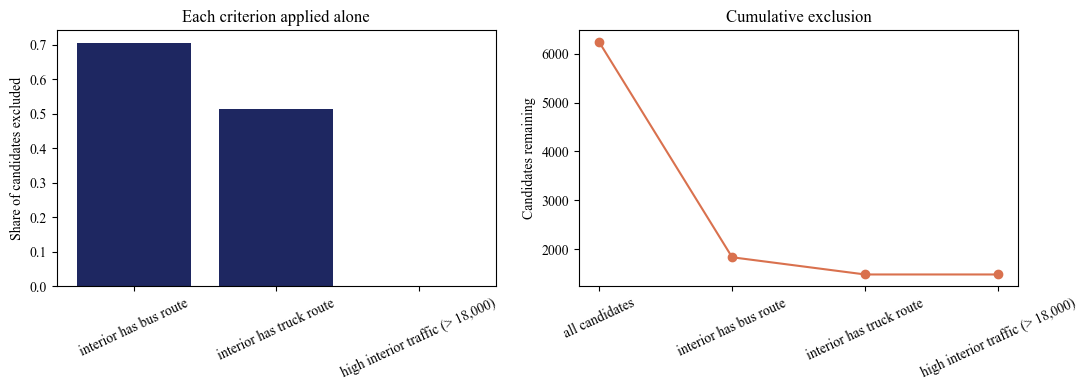

In [73]:
plt.rcParams["font.family"] = "Times New Roman"

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(individually["criterion"], individually["share_excluded_alone"], color="#1E2761")
axes[0].set_ylabel("Share of candidates excluded")
axes[0].set_title("Each criterion applied alone")
axes[0].tick_params(axis="x", rotation=25)

axes[1].plot(["all candidates"] + cumulative["criterion"].tolist(),
             [len(criteria_table)] + cumulative["remaining_after"].tolist(), marker="o", color="#D9714E")
axes[1].set_ylabel("Candidates remaining")
axes[1].set_title("Cumulative exclusion")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### 5.2 Suitability scoring & ranking

In [71]:
DEFAULT_WEIGHTS = {
    "share_interior_local_norm": 0.3,
    "population_norm": 0.3,
    "perimeter_capacity_norm": 0.2,
    "max_interior_volume_norm": -0.2,  # lower interior volume is better
}

def suitability_score(df, weights=DEFAULT_WEIGHTS):
    df = df.copy()
    df["suitability_score"] = sum(df[col] * w for col, w in weights.items())
    return df.sort_values("suitability_score", ascending=False).reset_index(drop=True)

scored = suitability_score(survivors)
top10 = scored.head(10)
top10[["unit_id", "suitability_score"]]

,unit_id,suitability_score
0,A3766-3767_S-1124--1121,0.487129
1,A3813-3814_S-1047--1044,0.487076
2,A3877-3878_S-1014--1011,0.474744
3,A3668-3669_S-1158--1155,0.465256
4,A3876-3877_S-1014--1011,0.455619
5,A3793-3794_S-1104--1101,0.449219
6,A3851-3852_S-1023--1020,0.440271
7,A3690-3691_S-1174--1171,0.425252
8,A3811-3812_S-1076--1073,0.424518
9,A3667-3668_S-1172--1169,0.419435


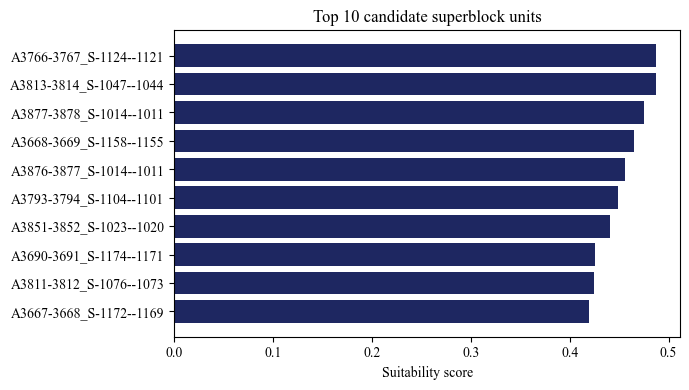

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top10["unit_id"][::-1], top10["suitability_score"][::-1], color="#1E2761")
ax.set_xlabel("Suitability score")
ax.set_title("Top 10 candidate superblock units")
plt.tight_layout()
plt.show()

### 5.3 Sensitivity analysis — is the ranking robust to modeling choices?

In [75]:
WEIGHT_VARIANTS = {
    "baseline": DEFAULT_WEIGHTS,
    "traffic_averse": {"share_interior_local_norm": 0.2, "population_norm": 0.2,
                        "perimeter_capacity_norm": 0.1, "max_interior_volume_norm": -0.5},
    "population_first": {"share_interior_local_norm": 0.15, "population_norm": 0.6,
                          "perimeter_capacity_norm": 0.1, "max_interior_volume_norm": -0.15},
}

def sensitivity_analysis(df, weight_variants=WEIGHT_VARIANTS):
    rank_cols = {}
    for name, weights in weight_variants.items():
        s = suitability_score(df, weights).set_index("unit_id")["suitability_score"]
        rank_cols[name] = s.rank(ascending=False)
    rank_df = pd.DataFrame(rank_cols)
    return rank_df, rank_df.corr(method="spearman")

rank_df, corr = sensitivity_analysis(survivors)
print(corr.round(2))

                  baseline  traffic_averse  population_first
baseline              1.00            0.98              0.89
traffic_averse        0.98            1.00              0.87
population_first      0.89            0.87              1.00


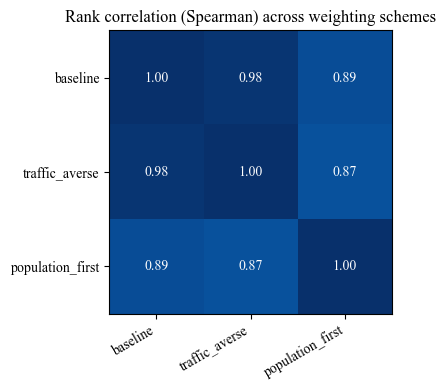

In [76]:
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(corr.values, vmin=0, vmax=1, cmap="Blues")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=30, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", color="white" if corr.values[i,j] > 0.5 else "black")
ax.set_title("Rank correlation (Spearman) across weighting schemes")
plt.tight_layout()
plt.show()

### 5.4 Disruption assessment — what does closing the top candidate cost?

In [77]:
def disruption_assessment(G, unit, n_pairs=200, seed=0):
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    idx = rng.choice(len(nodes), size=min(n_pairs * 2, len(nodes)), replace=False)
    sample = [nodes[i] for i in idx]
    pairs = list(zip(sample[::2], sample[1::2]))

    def avg_path_len(graph, pairs):
        vals = []
        for s, t in pairs:
            try:
                vals.append(nx.shortest_path_length(graph, s, t, weight="length"))
            except nx.NetworkXNoPath:
                continue
        return float(np.mean(vals)) if vals else np.nan

    before = avg_path_len(G, pairs)
    G_closed = G.copy()
    G_closed.remove_edges_from(unit["interior_edges"])
    after = avg_path_len(G_closed, pairs)

    interior_vol = sum(G[u][v][k].get("adt_volume", 0) for u, v, k in unit["interior_edges"])
    perim_before = sum(G[u][v][k].get("adt_volume", 0) for u, v, k in unit["perimeter_edges"])

    return {
        "unit_id": unit["unit_id"],
        "avg_path_len_before": before,
        "avg_path_len_after": after,
        "pct_increase": (after - before) / before * 100 if before else np.nan,
        "perimeter_capacity_before": perim_before,
        "perimeter_capacity_after_upper_bound": perim_before + interior_vol,  # all displaced traffic -> perimeter
    }

top_unit_id = scored.iloc[0]["unit_id"]
top_unit = next(u for u in candidate_units if u["unit_id"] == top_unit_id)
disruption_result = disruption_assessment(G, top_unit)
pd.Series(disruption_result)

unit_id                                 A3766-3767_S-1124--1121
avg_path_len_before                                 7081.216309
avg_path_len_after                                  7081.216309
pct_increase                                                0.0
perimeter_capacity_before                                 36000
perimeter_capacity_after_upper_bound                      37500
dtype: object

## 6. Discussion

**How much of Manhattan is excluded, and by what.** Of 6,241 candidate
units generated across the grid, **1,484 survive hard exclusion (23.8%)**.
The two real filters do almost all of the work: **70.6%** of candidates are
excluded outright because an interior street carries a **bus route**, and
**51.3%** because an interior street is a **designated truck route**
(applied cumulatively: bus removes 4,405 candidates first, truck removes a
further 352 from what's left). The **traffic-volume** filter removes
essentially nothing (0.1%) — not because Manhattan traffic is uniformly low,
but because most interior segments never received a real DOT count and were
imputed at their hierarchy-class median, which collapses right onto the
75th-percentile threshold. **In short: on this data, bus and truck routes —
not traffic volume — are what structurally rule out most of Manhattan.**
That's itself an answer to the research question: Manhattan's transit and
freight network, laid over a much finer grid than Barcelona's, is the
binding constraint, more than raw car traffic.

**The ranked shortlist.** The top candidate is **A3766-3767_S-1124–1121**
(suitability score 0.487), with **A3813-3814_S-1047–1044** a close second
(0.487). The next several candidates cluster in the 0.42–0.47 range before
trailing off, suggesting a small set of genuinely strong candidates rather
than one clear outlier.

**Is the ranking robust?** Spearman rank correlation across the three
weighting schemes is **0.98 (baseline vs. traffic-averse), 0.89 (baseline vs.
population-first), and 0.87 (traffic-averse vs. population-first)** — all
comfortably high. The shortlist is **not an artifact of the particular
weights chosen**; the same neighborhoods surface whether the model leans
toward penalizing traffic or rewarding population served.

**The disruption cost — and a real limitation.** For the top candidate,
closing interior streets produced **0.0% change** in average shortest-path
length across 200 random Manhattan-wide node pairs, and perimeter capacity
moved only from 36,000 to an upper-bound 37,500. Read literally this says
"no disruption," but that's almost certainly a **measurement artifact, not a
real finding**: a single candidate unit covers a tiny fraction of the street
grid, so random Manhattan-wide OD pairs essentially never route through it —
the sampling can't see a local effect. A fairer test would sample trips that
specifically originate or end near the candidate unit, not uniformly across
all of Manhattan. This is flagged here rather than smoothed over, since it
changes how the disruption result should be read: absence of evidence, not
evidence of absence.

**Interpretation caveats.**
- A high suitability score identifies **structural feasibility only**.
  Community preferences, economic effects (including the gentrification risk
  documented in Barcelona's own superblock areas), emergency access, and
  curb-use details are outside the scope of this data.
- The **traffic-volume criterion is currently under-powered**: real DOT
  coverage was sparse (142 of 8,208 edges measured), so most candidates were
  screened on imputed values that happen to sit near the exclusion threshold.
  A stricter version of this analysis would drop candidates whose interior
  volume is entirely imputed rather than scoring them as if it were measured.
- The **disruption assessment underestimates local effects** for the reason
  above — it's an upper bound in the sense that it also assumes all displaced
  traffic lands on the perimeter with no trip reduction, but a lower bound in
  the sense that random sampling missed the effect entirely for this
  candidate.
- The candidate-unit geometry (avenue pair × cross-street run) is a
  **modeling decision**, not a literal translation of Barcelona's 3×3 block
  grid — a different window size would shift which specific units rank
  highest, though Section 5.3 suggests the broad pattern is stable.

**Answer to the research question.** Roughly a quarter of the Manhattan grid
structurally survives a Barcelona-style screening, and the ranking of where
is stable across reasonable modeling choices. But the binding constraint
isn't traffic volume, the thing Barcelona's own program targets most
directly — it's the density of bus and truck routes threading through
Manhattan's much finer grid. That's a structural difference from Barcelona
worth stating plainly, not just a data limitation.

**Next steps.** Re-run the disruption assessment (5.4) with OD pairs sampled
near each top candidate rather than uniformly across Manhattan; tighten the
traffic-volume filter to distinguish measured from imputed segments; map the
top 10 candidates against neighborhood boundaries to check for spatial
clustering; and, if time allows, compare the 23.8% survival share against
Eggimann (2022)'s published figures for other grid cities as an external
sanity check.

## Reference and Tools

**Key reference:** Eggimann, S. (2022). The potential of implementing
superblocks for multifunctional street use in cities. *Nature
Sustainability*, 5, 406–414. https://doi.org/10.1038/s41893-022-00855-2

**Tools:** `osmnx`, `networkx`, `geopandas`, `shapely`, `pandas`, `numpy`,
`requests`, `matplotlib`, `scipy` (Spearman rank correlation).